## Load datasets in the form of .txt files with columns (M, R), compute KDEs, evaluate KDEs on fine grid (Mass and Radius columns of Table 1).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
import seaborn as sns
import matplotlib as mpl

# Model definitions
MODELS = {
    "ST_PST19": dict(file="datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
    "ST_PDT":   dict(file="datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra23: ST+PDT"),
    "ST_PST":   dict(file="datafiles/ST_PST",   color="tab:orange", label="Vinciguerra23: ST+PST"),
    "PDT_U":    dict(file="datafiles/PDT_U",    color="tab:green",  label="Vinciguerra23: PDT--U"),
    "ST_U":     dict(file="datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra23: ST--U"),
    "2spot":    dict(file="datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
    "3spot":    dict(file="datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
    "PDT_U26": dict(file="datafiles/PDT_U26",  color="tab:olive",  label="Kini26: PDT--U"),
}

# Data and sample stats
samples_MR = {}
M_med, M_lo, M_hi, M_16, M_84, S_Mi= {}, {}, {}, {}, {}, {}
R_med, R_lo, R_hi, R_16, R_84, S_Ri = {}, {}, {}, {}, {}, {}
KDEs_2D = {}

for key, meta in MODELS.items():
    filename = meta["file"]

    data = np.loadtxt(filename)
    M, R = data.T[0], data.T[1]
    samples_MR[key] = np.vstack([M, R])

    # Mass statistics
    M_med[key] = np.median(M)
    M_lo[key]  = np.min(M)
    M_hi[key]  = np.max(M)
    M_16[key] = np.percentile(M, 16)
    M_84[key] = np.percentile(M, 84)
    S_Mi[key]  = max(M_hi[key] - M_med[key],
                     M_med[key] - M_lo[key])

    # Radius statistics
    R_med[key] = np.median(R)
    R_lo[key]  = np.min(R)
    R_hi[key]  = np.max(R)
    R_16[key] = np.percentile(R, 16)
    R_84[key] = np.percentile(R, 84)
    S_Ri[key]  = max(R_hi[key] - R_med[key],
                     R_med[key] - R_lo[key])

    print(
        rf"{meta['label']}: "
        rf"M = {M_med[key]:.3f} (+{M_84[key] - M_med[key]:.3f}/-{M_med[key] - M_16[key]:.3f}), "
        rf"R = {R_med[key]:.3f} (+{R_84[key] - R_med[key]:.3f}/-{R_med[key] - R_16[key]:.3f})"
    )

    # KDEs
    KDEs_2D[key] = gaussian_kde(samples_MR[key], bw_method="silverman")

M_grid = np.linspace(0.95, 2.2, 100)
dM = M_grid[1] - M_grid[0]

R_grid = np.linspace(9.0, 17.0, 100)
dR = R_grid[1] - R_grid[0]
MM, RR = np.meshgrid(M_grid, R_grid, indexing="ij")
pos = np.vstack([MM.ravel(), RR.ravel()])

# Using dict is more convenient for the multi-dimensional case, g_dict = KDEs_2D normalized.
g_dict = {}
for key in MODELS:

    g = KDEs_2D[key](pos).reshape(MM.shape)
    g /= np.trapz(
            np.trapz(g, R_grid, axis=1),
            M_grid
        )
    g_dict[key] = g
g_stack = np.array([g_dict[key] for key in MODELS]) # shape: (Ndata, NM, NR)

Riley19: ST+PST: M = 1.289 (+0.174/-0.157), R = 12.574 (+1.368/-1.294)
Vinciguerra23: ST+PDT: M = 1.395 (+0.128/-0.117), R = 11.714 (+0.872/-0.826)
Vinciguerra23: ST+PST: M = 1.927 (+0.097/-0.124), R = 15.232 (+0.524/-0.843)
Vinciguerra23: PDT--U: M = 1.702 (+0.183/-0.190), R = 14.435 (+0.877/-1.046)
Vinciguerra23: ST--U: M = 1.883 (+0.132/-0.189), R = 15.117 (+0.637/-1.314)
Miller19: 2spot: M = 1.442 (+0.175/-0.159), R = 13.271 (+1.300/-1.149)
Miller19: 3spot: M = 1.440 (+0.153/-0.147), R = 13.012 (+1.253/-1.057)
Kini26: PDT--U: M = 1.435 (+0.204/-0.167), R = 12.678 (+1.309/-1.041)


S_Mi.values()

## Construct combined posterior in M and R (2D case, Section 3.2)

In [2]:
# Grids and Priors for the systematic-error parameters
# We are very insensitive to the ranges set here as long as they are sufficiently large
avg_S_Mi = np.mean(list(S_Mi.values())) 
sigma_M_grid = np.logspace(-10*avg_S_Mi, -0.1*avg_S_Mi, 10)
prior_sigma_M = 1.0 / sigma_M_grid
prior_sigma_M /= np.trapz(prior_sigma_M, sigma_M_grid)

avg_S_Ri = np.mean(list(S_Ri.values()))
sigma_R_grid = np.logspace(-10*avg_S_Ri, -0.1*avg_S_Ri, 10)
prior_sigma_R = 1.0 / sigma_R_grid
prior_sigma_R /= np.trapz(prior_sigma_R, sigma_R_grid)

alpha_grid = np.linspace(1.0, 10, 80)
prior_alpha = np.exp(-(alpha_grid))
prior_alpha /= np.trapz(prior_alpha, alpha_grid)

p_grid = np.linspace(0.0, 1.0, 40) # prior on p is flat

# Precompute bad distributions b_i(M,R | sigma_M, sigma_R)
b_dict = {}

for key in MODELS:

    mu_M = M_med[key]
    mu_R = R_med[key]

    b_sigma = []

    for sigma_M in sigma_M_grid:
        row_sigma_R = []

        for sigma_R in sigma_R_grid:

            b_alpha = []

            for alpha in alpha_grid:

                var_M = (alpha * S_Mi[key])**2 + sigma_M**2
                var_R = (alpha * S_Ri[key])**2 + sigma_R**2

                b = (
                    norm.pdf(MM, loc=mu_M, scale=np.sqrt(var_M)) *
                    norm.pdf(RR, loc=mu_R, scale=np.sqrt(var_R))
                )

                b /= np.trapz(
                        np.trapz(b, R_grid, axis=1),
                        M_grid
                    )

                b_alpha.append(b)

            b_alpha = np.array(b_alpha)

            # Marginalize over alpha
            b_marg = np.trapz(
                b_alpha * prior_alpha[:, None, None],
                alpha_grid,
                axis=0
            )

            b_marg /= np.trapz(
                        np.trapz(b_marg, R_grid, axis=1),
                        M_grid
                    )

            row_sigma_R.append(b_marg)

        b_sigma.append(row_sigma_R)

    b_dict[key] = np.array(b_sigma)

NsM = len(sigma_M_grid)
NsR = len(sigma_R_grid)

evidence_sigma_MR = np.zeros((NsM, NsR))
P_MR_given_sigma = np.zeros((NsM, NsR, len(M_grid), len(R_grid)))

for iM, sigma_M in enumerate(sigma_M_grid):
    for iR, sigma_R in enumerate(sigma_R_grid):

        b_stack = np.array([
            b_dict[key][iM, iR] for key in MODELS
        ])

        g_exp = g_stack[:, None, :, :]
        b_exp = b_stack[:, None, :, :]
        p_exp = p_grid[None, :, None, None]

        mixture = p_exp * g_exp + (1 - p_exp) * b_exp
        L_p = np.prod(mixture, axis=0)   # (Np, NM, NR)

        likelihood = np.trapz(L_p, p_grid, axis=0)

        Z = np.trapz(
                np.trapz(likelihood, R_grid, axis=1),
                M_grid
            )

        evidence_sigma_MR[iM, iR] = Z
        P_MR_given_sigma[iM, iR] = likelihood / Z

posterior_sigma_MR = (
    evidence_sigma_MR
    * prior_sigma_M[:, None]
    * prior_sigma_R[None, :]
)

posterior_sigma_MR /= np.trapz(
    np.trapz(posterior_sigma_MR, sigma_R_grid, axis=1),
    sigma_M_grid
)

# ------------------------------------------------------------
# Combination: P(M,R | sigma_M, sigma_R)
# ------------------------------------------------------------

posterior = np.zeros_like(MM)

for iM in range(NsM):
    for iR in range(NsR):

        posterior += (
            P_MR_given_sigma[iM, iR]
            * posterior_sigma_MR[iM, iR]
        )

# Integrate properly over σ grid
posterior = np.trapz(
                np.trapz(
                    P_MR_given_sigma * posterior_sigma_MR[:, :, None, None],
                    sigma_R_grid,
                    axis=1
                ),
                sigma_M_grid,
                axis=0
            )

posterior /= np.trapz(
                np.trapz(posterior, R_grid, axis=1),
                M_grid
            )

print("\n2D M–R combination complete.")
# ------------------------------------------------------------
# Marginal posteriors for M and R
# ------------------------------------------------------------

posterior_sigma_MR = (
    evidence_sigma_MR *
    prior_sigma_M[:, None] *
    prior_sigma_R[None, :]
)

posterior_sigma_MR /= np.trapz(
    np.trapz(posterior_sigma_MR, sigma_R_grid, axis=1),
    sigma_M_grid
)

# P(M) = ∫ P(M,R) dR
P_M = np.trapz(posterior, R_grid, axis=1)
P_M /= np.trapz(P_M, M_grid)

# P(R) = ∫ P(M,R) dM
P_R = np.trapz(posterior, M_grid, axis=0)
P_R /= np.trapz(P_R, R_grid)

# ------------------------------------------------------------
# Credible intervals (16%, 50%, 84%)
# ------------------------------------------------------------

def credible_intervals(grid, pdf):
    cdf = np.cumsum(pdf) * (grid[1] - grid[0])
    quantiles = [0.16, 0.50, 0.84]
    values = np.interp(quantiles, cdf, grid)
    return values

M_q16, M_q50, M_q84 = credible_intervals(M_grid, P_M)
R_q16, R_q50, R_q84 = credible_intervals(R_grid, P_R)

print("\nFinal marginalized constraints:")
print(f"M = {M_q50:.4f}+{M_q84 - M_q50:.4f}/-{M_q50 - M_q16:.4f} SM")
print(f"R = {R_q50:.4f}+{R_q84 - R_q50:.4f}/-{R_q50 - R_q16:.4f} km")

# Draw 10000 samples from the posterior and save as .txt file
n_samples = 10000
posterior_flat = posterior.ravel()
posterior_flat /= np.sum(posterior_flat)
indices = np.random.choice(len(posterior_flat), size=n_samples, p=posterior_flat)
M_samples = MM.ravel()[indices]
R_samples = RR.ravel()[indices]
np.savetxt("combined_posterior.txt", np.vstack([M_samples, R_samples]).T, header="M R")


2D M–R combination complete.

Final marginalized constraints:
M = 1.4647+0.0890/-0.0841 SM
R = 12.6865+0.6377/-0.5459 km


## Plot combined posterior in M and R (Figure 2, Section 3.2)

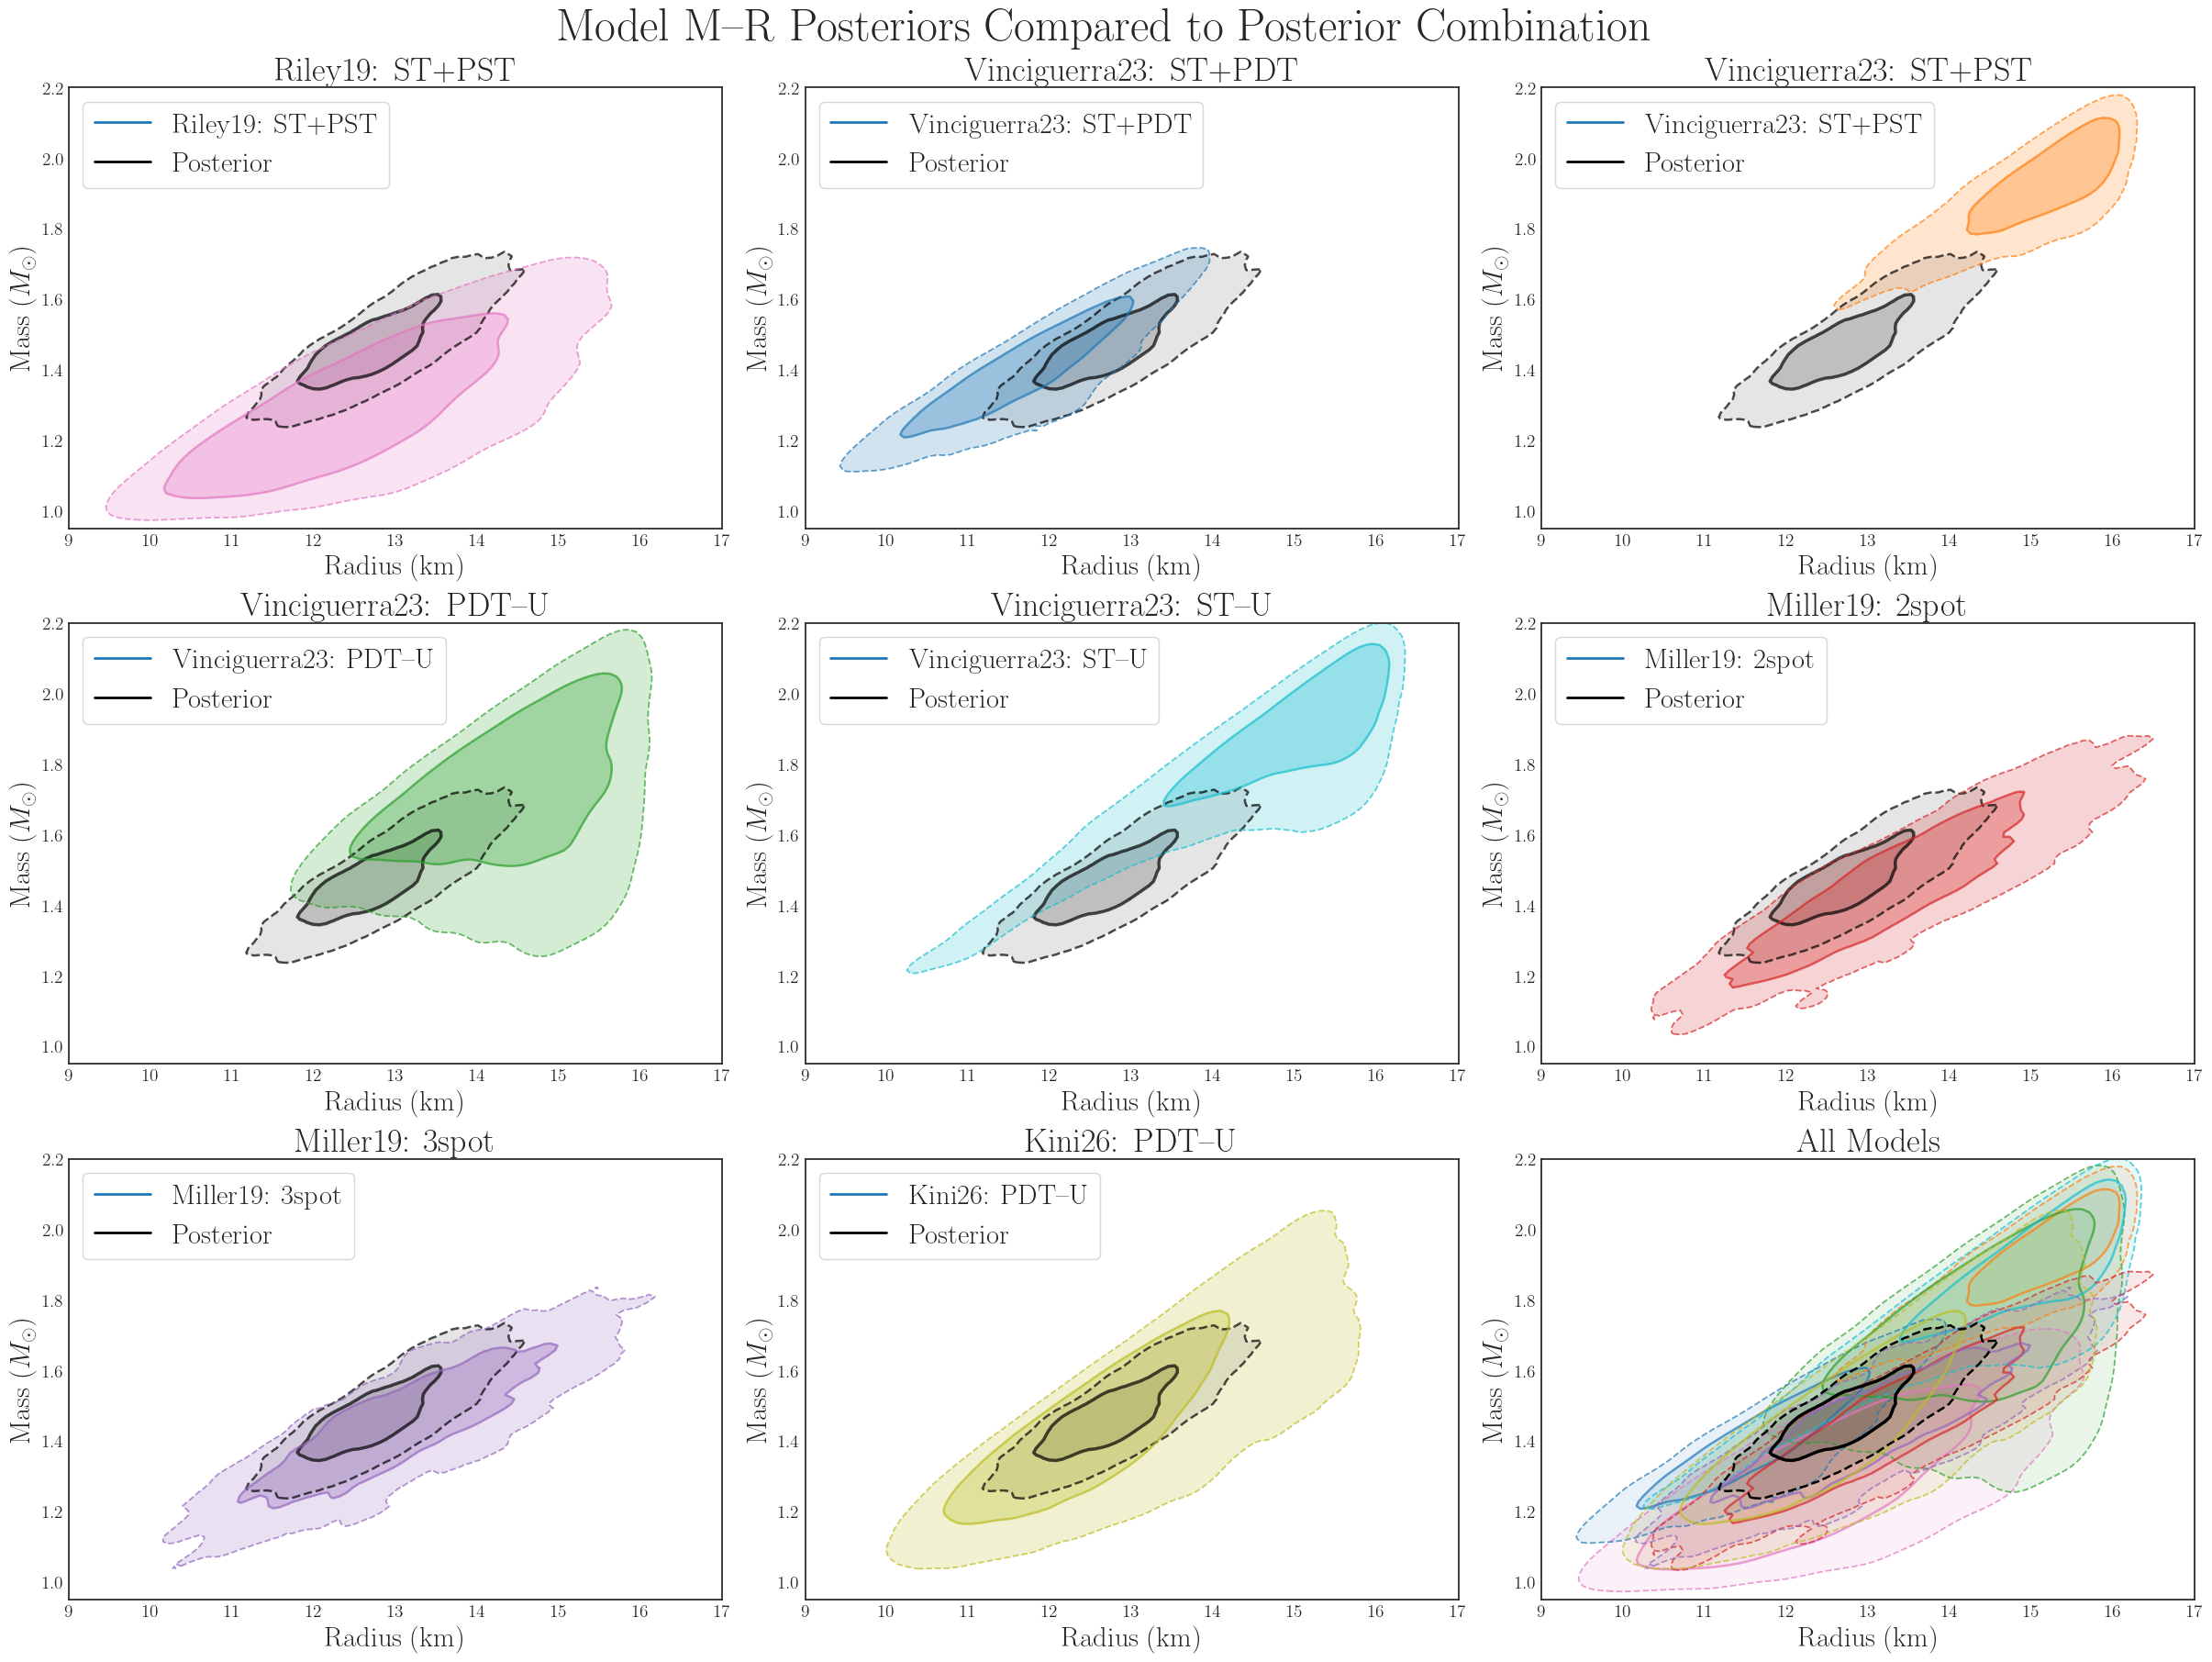

In [3]:
# Flatten posterior
flat = posterior.ravel()
sorted_idx = np.argsort(flat)[::-1]
sorted_pdf = flat[sorted_idx]

# Cumulative probability
cumulative = np.cumsum(sorted_pdf)
cumulative /= cumulative[-1]

# Find thresholds for 68% and 95%
level_68 = sorted_pdf[np.searchsorted(cumulative, 0.68)]
level_95 = sorted_pdf[np.searchsorted(cumulative, 0.95)]

plt.style.use('seaborn-v0_8-white')
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# ------------------------------------------------------------
# HDR level computation
# ------------------------------------------------------------

def compute_hdr_levels(pdf, probs=(0.68, 0.95)):

    flat = pdf.ravel()
    idx = np.argsort(flat)[::-1]
    sorted_pdf = flat[idx]

    cumsum = np.cumsum(sorted_pdf)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        levels.append(sorted_pdf[np.searchsorted(cumsum, p)])

    return levels


# Posterior levels
posterior_lvl68, posterior_lvl95 = compute_hdr_levels(posterior, (0.68, 0.95))

# Models to compare
compare_series = [
    (key, MODELS[key]["label"])
    for key in MODELS
]

#3x3
fig, axes = plt.subplots(3, 3, figsize=(24, 18), constrained_layout=True)
axes = axes.flatten()

def rgba(color, alpha):
    return mpl.colors.to_rgba(color, alpha)

# ------------------------------------------------------------
# Panels 1–7: individual vs posterior
# ------------------------------------------------------------

for ax, (key, label) in zip(axes[:len(compare_series)], compare_series):

    density = g_dict[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Posterior fill
    ax.contourf(
        R_grid, M_grid, posterior,
        levels=[posterior_lvl95, posterior_lvl68, posterior.max()],
        colors=[rgba("black", 0.10), rgba("black", 0.25)],
        antialiased=True
    )

    # Individual fill
    ax.contourf(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68, density.max()],
        colors=[rgba(MODELS[key]["color"], 0.20), rgba(MODELS[key]["color"], 0.45)],
        antialiased=True
    )

    # Posterior outline
    ax.contour(
        R_grid, M_grid, posterior,
        levels=[posterior_lvl95, posterior_lvl68],
        colors=rgba("black", 0.7),
        linewidths=[1.8, 2.5],
        linestyles=['--', '-']
    )

    # Individual outline
    ax.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=rgba(MODELS[key]["color"], 0.7),
        linewidths=[1.3, 1.8],
        linestyles=['--', '-'],
    )

    ax.set_title(label, fontsize=26)
    ax.set_xlabel("Radius (km)", fontsize=22)
    ax.set_ylabel("Mass ($M_\\odot$)", fontsize=22)
    ax.minorticks_on()
    ax.tick_params(labelsize=14)

    ax.legend(
        handles=[
            mpl.lines.Line2D([], [], color='tab:blue', linewidth=2, label=label),
            mpl.lines.Line2D([], [], color='black', linewidth=2, label='Posterior')
        ],
        fontsize=22,
        loc='upper left',
        frameon=True,
        fancybox=True,
        framealpha=0.8
    )

# ------------------------------------------------------------
# Panel 8: all models + posterior
# ------------------------------------------------------------

ax_all = axes[-1]

for key, label in compare_series:

    density = g_dict[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Individual fill
    ax_all.contourf(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68, density.max()],
        colors=[rgba(MODELS[key]["color"], 0.10), rgba(MODELS[key]["color"], 0.2)],
        antialiased=True
    )
    
    # Individual outline
    ax_all.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=rgba(MODELS[key]["color"], 0.7),
        linewidths=[1.3, 1.8],
        linestyles=['--', '-'],
    )

# Posterior fill
ax_all.contourf(
    R_grid, M_grid, posterior,
    levels=[posterior_lvl95, posterior_lvl68, posterior.max()],
    colors=[rgba("black", 0.10), rgba("black", 0.25)],
    antialiased=True
)

# Posterior outline
ax_all.contour(
    R_grid, M_grid, posterior,
    levels=[posterior_lvl95, posterior_lvl68],
    colors='black',
    linewidths=[1.8, 2.5],
    linestyles=['--', '-']
)

ax_all.set_title("All Models", fontsize=26)
ax_all.set_xlabel("Radius (km)", fontsize=22)
ax_all.set_ylabel("Mass ($M_\\odot$)", fontsize=22)
ax_all.minorticks_on()
ax_all.tick_params(labelsize=14)

fig.suptitle(
    "Model M--R Posteriors Compared to Posterior Combination",
    fontsize=36
)

plt.show()
posterior_2d = posterior  # for naming consistency

# ------------------------------------------------------------
# Marginal distributions
# ------------------------------------------------------------

# P(R) = ∫ P(M,R) dM
P_R = np.trapz(posterior_2d, M_grid, axis=0)
P_R /= np.trapz(P_R, R_grid)

# P(M) = ∫ P(M,R) dR
P_M = np.trapz(posterior_2d, R_grid, axis=1)
P_M /= np.trapz(P_M, M_grid)

# Quantiles (16%, 50%, 84%) — properly normalized
def compute_quantiles(grid, pdf):
    cdf = np.cumsum(pdf) * (grid[1] - grid[0])
    cdf /= cdf[-1]
    return np.interp([0.16, 0.5, 0.84], cdf, grid)

R_q16, R_q50, R_q84 = compute_quantiles(R_grid, P_R)
M_q16, M_q50, M_q84 = compute_quantiles(M_grid, P_M)

## Plot the combined posterior with marginal distributions in M and R (Figure 3, Section 3.2)

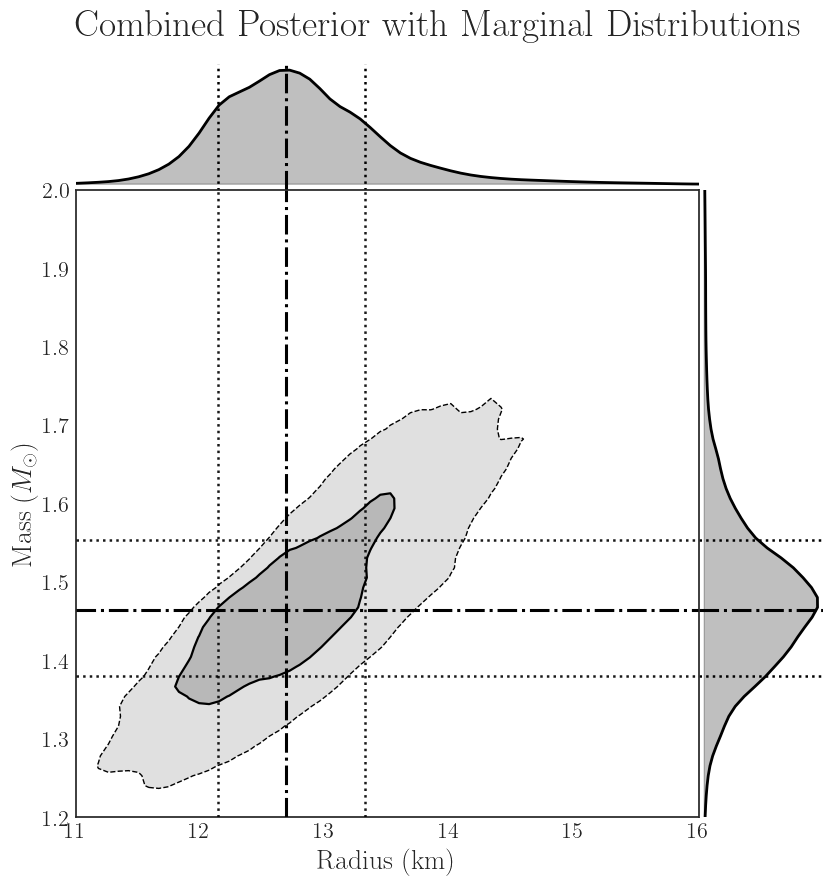


 marginalized M constraints:
1.4646687866661698+0.08904368109981609-0.0841

 marginalized R constraints:
12.686479094106925+0.6377237386749712-0.5459


In [4]:

# ------------------------------------------------------------
# HDR levels for 2D posterior
# ------------------------------------------------------------

def compute_hdr_levels(pdf, probs=(0.68, 0.95)):
    flat = pdf.ravel()
    idx = np.argsort(flat)[::-1]
    sorted_pdf = flat[idx]

    cumsum = np.cumsum(sorted_pdf)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        levels.append(sorted_pdf[np.searchsorted(cumsum, p)])

    return levels

lvl68, lvl95 = compute_hdr_levels(posterior_2d, (0.68, 0.95))
levels = [lvl95, lvl68, posterior_2d.max()]

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

plt.style.use('seaborn-v0_8-white')
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

fontsize = 27
label_fs = 20
tick_fs = 16

g = sns.JointGrid(height=8, space=0)

# Zoom window (adjust if desired)
zoom_R_min, zoom_R_max = 11.0, 16.0
zoom_M_min, zoom_M_max = 1.2, 2.0

g.ax_joint.set_xlim(zoom_R_min, zoom_R_max)
g.ax_joint.set_ylim(zoom_M_min, zoom_M_max)
g.ax_marg_x.set_xlim(zoom_R_min, zoom_R_max)
g.ax_marg_y.set_ylim(zoom_M_min, zoom_M_max)

# ------------------------------------------------------------
# 2D Posterior contours
# ------------------------------------------------------------

g.ax_joint.contourf(
    R_grid, M_grid, posterior_2d,
    levels=levels,
    colors=[
        mpl.colors.to_rgba('black', 0.12),
        mpl.colors.to_rgba('black', 0.28)
    ],
    antialiased=True
)

g.ax_joint.contour(
    R_grid, M_grid, posterior_2d,
    levels=[lvl95, lvl68],
    colors='black',
    linewidths=[1.0, 1.6],
    linestyles=['--', '-']
)

# ------------------------------------------------------------
# 68% marginal guide lines (joint panel)
# ------------------------------------------------------------

for q in (R_q16, R_q84):
    g.ax_joint.axvline(
        q,
        color='black',
        linestyle=':',
        linewidth=1.8,
        alpha=0.9,
        zorder=10
    )

for q in (M_q16, M_q84):
    g.ax_joint.axhline(
        q,
        color='black',
        linestyle=':',
        linewidth=1.8,
        alpha=0.9,
        zorder=10
    )

# Median lines
g.ax_joint.axvline(R_q50, color='black', linestyle='-.', linewidth=2.2, zorder=10)
g.ax_joint.axhline(M_q50, color='black', linestyle='-.', linewidth=2.2, zorder=10)

# ------------------------------------------------------------
# Marginal panels
# ------------------------------------------------------------

g.ax_marg_x.plot(R_grid, P_R, color='black', lw=2)
g.ax_marg_x.fill_between(R_grid, P_R, color='black', alpha=0.25)

g.ax_marg_y.plot(P_M, M_grid, color='black', lw=2)
g.ax_marg_y.fill_betweenx(M_grid, P_M, color='black', alpha=0.25)

# 68% CI dotted lines (marginals)
for q in (R_q16, R_q84):
    g.ax_marg_x.axvline(q, color='black', linestyle=':', linewidth=1.8)

for q in (M_q16, M_q84):
    g.ax_marg_y.axhline(q, color='black', linestyle=':', linewidth=1.8)

# Median lines
g.ax_marg_x.axvline(R_q50, color='black', linestyle='-.', linewidth=2.2)
g.ax_marg_y.axhline(M_q50, color='black', linestyle='-.', linewidth=2.2)

# ------------------------------------------------------------
# Labels & ticks
# ------------------------------------------------------------

g.ax_joint.set_xlabel("Radius (km)", fontsize=label_fs)
g.ax_joint.set_ylabel("Mass ($M_\\odot$)", fontsize=label_fs)

g.ax_joint.tick_params(labelsize=tick_fs, which='both', top=True, right=True)
g.ax_marg_x.tick_params(labelsize=tick_fs - 2)
g.ax_marg_y.tick_params(labelsize=tick_fs - 2)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

g.fig.suptitle(
    "Combined Posterior with Marginal Distributions",
    fontsize=fontsize,
    y=1.05
)

# ------------------------------------------------------------
# Save & show
# ------------------------------------------------------------

g.fig.savefig(
    "figures/MarginalPosteriors.png",
    dpi=300
)

plt.show()

print("\n marginalized M constraints:")
print(f"{M_q50}+{(M_q84 - M_q50)}-{(M_q50 - M_q16):.4f}")

print("\n marginalized R constraints:")
print(f"{R_q50}+{(R_q84 - R_q50)}-{(R_q50 - R_q16):.4f}")
# Compute P(v_i = 1 | all data)

posterior_sigma_MR = evidence_sigma_MR * \
                     prior_sigma_M[:,None] * \
                     prior_sigma_R[None,:]

posterior_sigma_MR /= np.trapz(
    np.trapz(posterior_sigma_MR, sigma_R_grid, axis=1),
    sigma_M_grid
)

## 'Credibility' score (Table 2, Section 3.3)

In [5]:
# Score each individual measurement against the 2‑D posterior
# (approximate by marginalizing the bad component over the σ_M,σ_R posterior)
epsilon = 1e-300  # Tiny value to avoid divide-by-zero

# precompute marginal bad pdf for each dataset by integrating over sigma_M and sigma_R
b_marginal = {}
for key in MODELS:
    # b_dict[key] has shape (NsM, NsR, NM, NR)
    # weight with posterior_sigma_MR and integrate over both sigma axes
    # result has shape (NM, NR)
    weighted = b_dict[key] * posterior_sigma_MR[:, :, None, None]
    b_m = np.trapz(
            np.trapz(weighted, sigma_R_grid, axis=1),
            sigma_M_grid,
            axis=0
        )
    # normalize on M,R grid just to be safe
    norm = np.trapz(np.trapz(b_m, R_grid, axis=1), M_grid)
    if norm > 0:
        b_m /= norm
    b_marginal[key] = b_m

# iterate over the mass/radius grid
P_vi_1 = {}
for name in MODELS:
    prob_grid = np.zeros_like(posterior)  # (NM,NR)
    for i in range(len(M_grid)):
        for j in range(len(R_grid)):
            f_good = g_dict[name][i, j]
            f_bad_value = b_marginal[name][i, j]
            p_term = (p_grid * f_good) / (
                p_grid * f_good + (1 - p_grid) * f_bad_value + epsilon
            )
            prob_grid[i, j] = 1000*np.trapz(p_term, p_grid) * posterior[i, j]
    # integrate over M,R
    P_vi_1[name] = np.trapz(np.trapz(prob_grid, R_grid, axis=1), M_grid)
    print(f"Probability of {name} being good: {P_vi_1[name]:.4f}")

Probability of ST_PST19 being good: 0.6395
Probability of ST_PDT being good: 0.6897
Probability of ST_PST being good: 0.2013
Probability of PDT_U being good: 0.5915
Probability of ST_U being good: 0.4692
Probability of 2spot being good: 0.7259
Probability of 3spot being good: 0.8055
Probability of PDT_U26 being good: 0.8240


## Combined posterior compared with M--R contours of other neutron stars (Figure 4, Left Panel)

M1: Median in M: 1.5005^{+0.0969}_{-0.0885}
M1: Median in R: 10.7715^{+1.3415}_{-0.9032}
full smoothing factor for M1: 0.2644913097181993
M2: Median in M: 1.2387^{+0.0756}_{-0.0715}
M2: Median in R: 10.7271^{+1.3699}_{-0.858}
full smoothing factor for M2: 0.2644913097181993
J0437: Median in M: 1.4179^{+0.0364}_{-0.0366}
J0437: Median in R: 11.3576^{+0.9429}_{-0.6242}
full smoothing factor for J0437: 0.12884686950421398
posterior: Median in M: 1.4677^{+0.0884}_{-0.0758}
posterior: Median in R: 12.7172^{+0.6465}_{-0.5657}
full smoothing factor for posterior: 0.2154434690031884


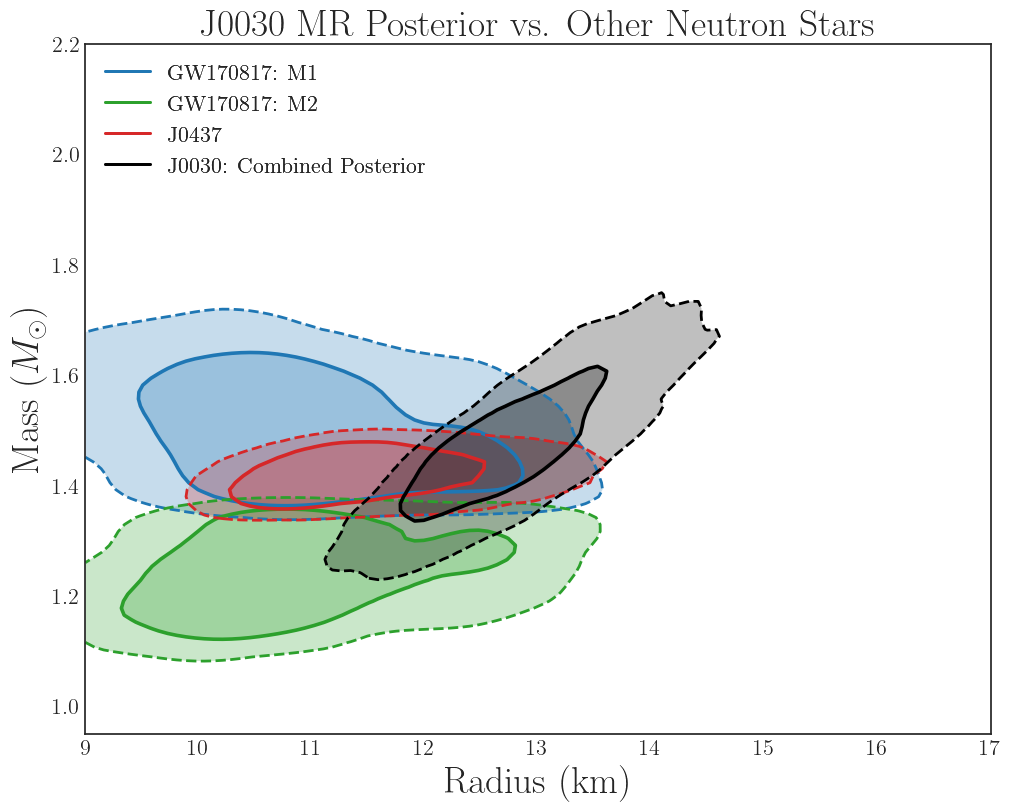

In [6]:
# Load Data (Mass vs Radius)
data_files = [
    ('M1', 'datafiles/GW170817_M1'),
    ('M2', 'datafiles/GW170817_M2'), 
     ('J0437', 'datafiles/J0437'),
    ('posterior', 'combined_posterior.txt')
]

datasets = {}
KDEs_2D = {}
M_sigma = {}
M_mu = {}
R_sigma = {}
R_mu = {}
bw_method = {}
for name, filename in data_files:
    data = np.loadtxt(filename)
    M, R = zip(*data.T[0:2].T)
    M_sigma[name] = (np.std(M))
    M_mu[name] = (np.mean(M))
    print(f"{name}: Median in M: {round(np.median(M), 4)}^{{+{round(np.percentile(M, 84)-np.median(M), 4)}}}_{{-{round(np.median(M)-np.percentile(M, 16), 4)}}}")
    R_sigma[name] = (np.std(R))
    R_mu[name] = (np.mean(R))
    print(f"{name}: Median in R: {round(np.median(R), 4)}^{{+{round(np.percentile(R, 84)-np.median(R), 4)}}}_{{-{round(np.median(R)-np.percentile(R, 16), 4)}}}")
    values = np.vstack([R, M])  # shape (2, N)
    datasets[name] = values
    KDEs_2D[name] = gaussian_kde(values, bw_method='silverman')
    print(f"full smoothing factor for {name}: {KDEs_2D[name].factor}")
    # KDEs_2D[name] = gaussian_kde(values, bw_method=0.1*KDEs_2D[name].factor)
    # print(f"0.1 times smoothing factor for {name}: {KDEs_2D[name].factor}")
    
# Set up 2D grid for Radius (x) and Mass (y)
R_mesh, M_mesh = np.meshgrid(R_grid, M_grid)
coords = np.vstack([R_mesh.ravel(), M_mesh.ravel()])  # shape (2, N_points)

# Precompute KDE values
KDE_grid_values = {}
for name in KDEs_2D:
    KDE_grid_values[name] = KDEs_2D[name].evaluate(coords).reshape(R_mesh.shape)

unique_series = [
    ('M1', 'tab:blue', 'GW170817: M1'),
    ('M2', 'tab:green', 'GW170817: M2'),
    ('J0437', 'tab:red', 'J0437'),
    ('posterior', 'black', 'J0030: Combined Posterior')
]

# Function to get density levels that enclose given probability mass (highest-density regions)
def compute_hdr_levels(density_grid, cred_levels=(0.68, 0.95)):
    vals = np.ravel(density_grid)
    sort_idx = np.argsort(vals)[::-1]
    sorted_vals = vals[sort_idx]
    cdf = np.cumsum(sorted_vals)
    cdf /= cdf[-1]
    levels = []
    for cl in cred_levels:
        # threshold where cumulative mass first exceeds cl
        idx = np.searchsorted(cdf, cl)
        levels.append(sorted_vals[idx])
    return levels

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

handles = []
for key, color, label in unique_series:
    density = KDE_grid_values[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Ensure levels are ascending for contourf
    levels = [lvl95, lvl68, density.max()]

    
    ax.contour(
    R_grid, M_grid, density,
    levels=[lvl95, lvl68],
    colors=[color, color],
    linewidths=[2.0, 2.6],
    linestyles=['--', '-']
    )
    cf = ax.contourf(
    R_grid, M_grid, density,
    levels=levels,
    colors=[mpl.colors.to_rgba(color, 0.25), mpl.colors.to_rgba(color, 0.45)],
    antialiased=True
    )

    # Dummy handle for legend with both 68/95 semantics represented once globally
    handle = mpl.lines.Line2D([], [], color=color, linewidth=2)
    handles.append((label, handle))

# Compose legend: one per dataset for color, plus a separate legend for credibility levels
legend1 = ax.legend([h for _, h in handles], [l for l, _ in handles], fontsize=16, loc='upper left')
ax.add_artist(legend1)

legend_lines = [
    mpl.lines.Line2D([], [], color='black', linestyle='-', linewidth=1.8, label='68% HDR'),
    mpl.lines.Line2D([], [], color='black', linestyle='--', linewidth=1.0, label='95% HDR'),
]

ax.set_xlabel('Radius (km)', fontsize=fontsize)
ax.set_ylabel('Mass ($M_\\odot$)', fontsize=fontsize)
ax.set_title('J0030 MR Posterior vs. Other Neutron Stars', fontsize=27)

# Optional: nicer axes limits and minor ticks
ax.set_xlim(R_grid.min(), R_grid.max())
ax.set_ylim(M_grid.min(), M_grid.max())
ax.minorticks_on()
ax.tick_params(which='both', top=True, right=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()